# House Price Prediction using Linear Regression

## Objective

The objective of this project is to build and evaluate a Linear Regression model using the California Housing Dataset. The model predicts the median house value based on different housing features such as median income, house age, average rooms, population, latitude, and longitude.

## Dataset Description

The California Housing Dataset contains 20,640 observations and 9 columns. It includes 8 input features and one target variable (MedHouseVal), which represents the median house value in California districts.

In [20]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [22]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [23]:
print(df.shape)

(20640, 9)


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the dataset. Histograms, correlation heatmaps, and scatter plots were used to analyze the distribution of variables and the relationship between different features and the target variable.

In [25]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


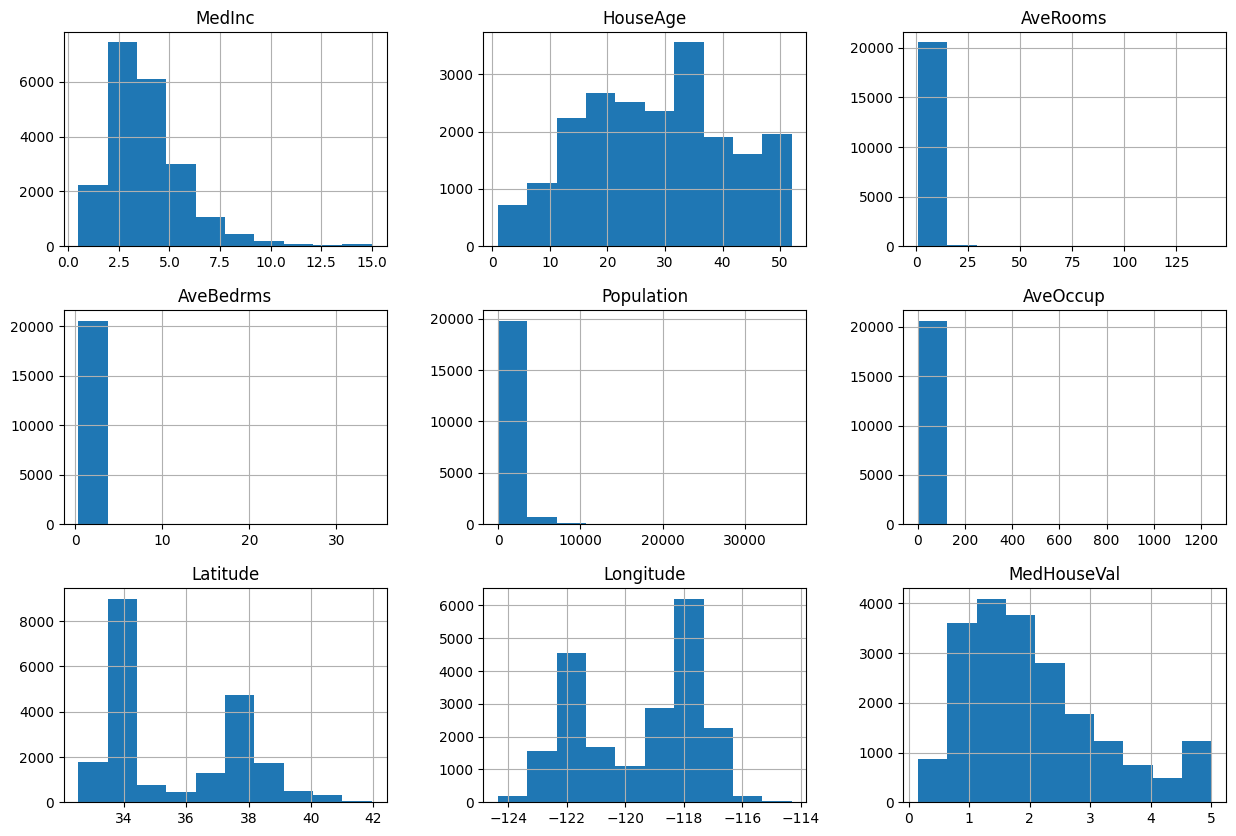

In [26]:
df.hist(figsize=(15,10))
plt.show()

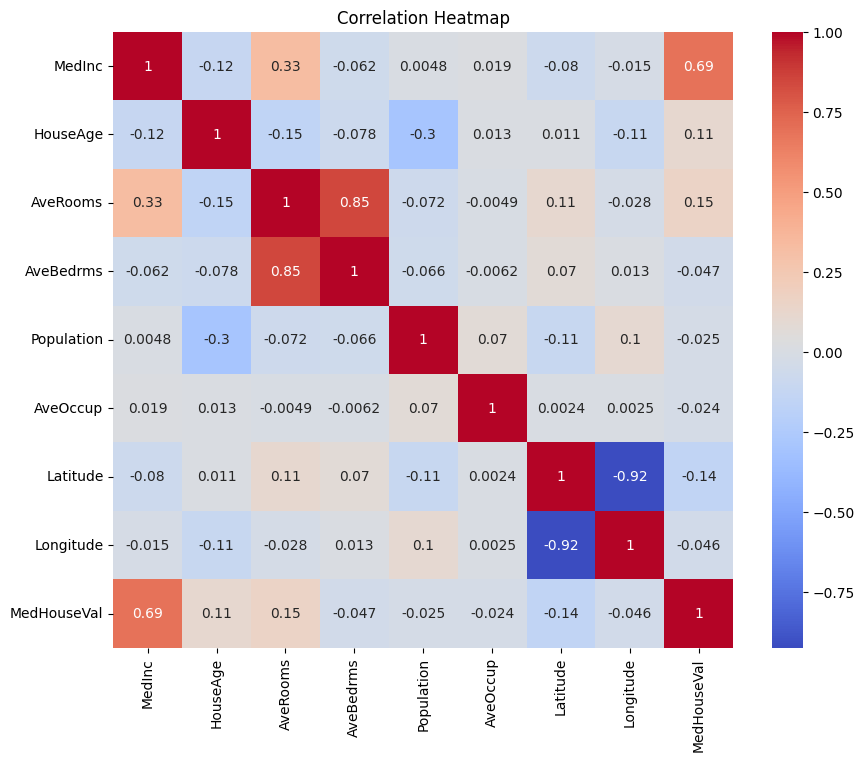

In [27]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

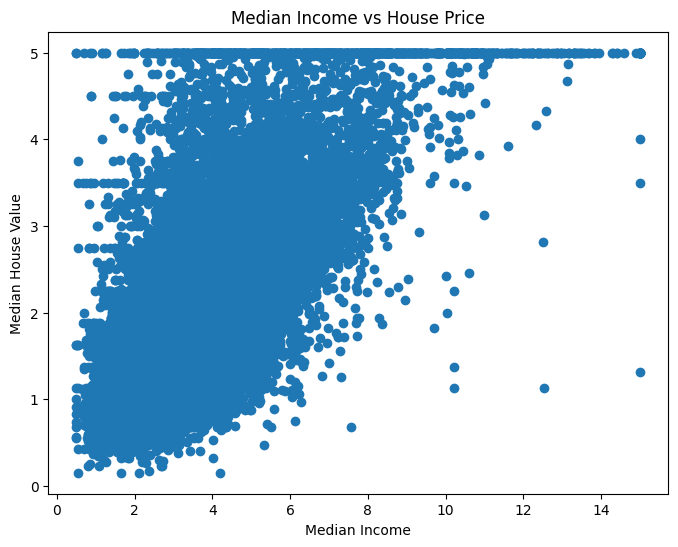

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(df["MedInc"], df["MedHouseVal"])

plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.title("Median Income vs House Price")

plt.show()

## Model Building

The dataset was divided into training and testing sets using an 80:20 ratio. A Linear Regression model was trained using the training dataset and later tested on unseen data.

In [29]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [33]:
y_pred = model.predict(X_test)

## Model Evaluation

The performance of the model was evaluated using three standard regression metrics:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [34]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 0.5332001304956553
Root Mean Squared Error : 0.7455813830127764
R2 Score : 0.5757877060324508


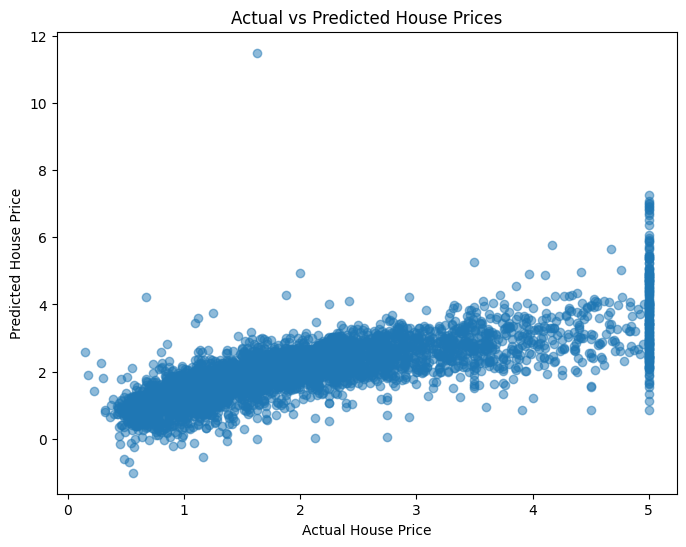

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

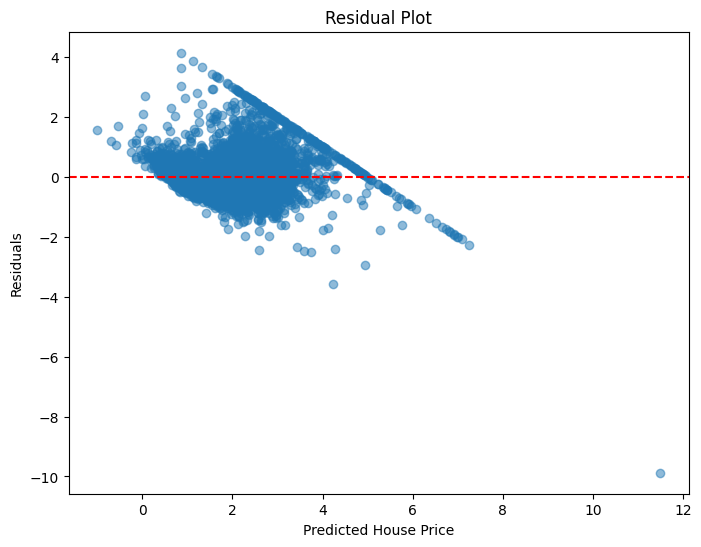

In [36]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [37]:
import pickle

with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

# Conclusion

- The California Housing dataset was successfully loaded and analyzed.
- Exploratory Data Analysis (EDA) was performed using histograms, a correlation heatmap, and scatter plots.
- A Linear Regression model was trained to predict median house prices.
- The model achieved:
  - Mean Absolute Error (MAE): 0.5332
  - Root Mean Squared Error (RMSE): 0.7456
  - R² Score: 0.5758
- The results indicate that the model provides a reasonable prediction performance.
- Future improvements could include using advanced regression models such as Random Forest Regressor, Gradient Boosting, or XGBoost to achieve higher accuracy.